# Weibo Discourse Analysis: Mental Health & Stranger Violence
**Project:** Mental Health and Violence in Chinese Public Discourse  
**Method:** BERTopic with `paraphrase-multilingual-MiniLM-L12-v2` + manual annotation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display

plt.rcParams['font.family'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE    = Path('.')
OUT_DIR = BASE / 'data/processed'
FIG_DIR = OUT_DIR / 'figures'

THEME_COLORS = {
    'Mental Illness & Law':  '#d62728',
    'Punishment & Justice':  '#ff7f0e',
    'Child Victims':         '#2ca02c',
    'Public Safety & Fear':  '#1f77b4',
    'Media & Info Control':  '#9467bd',
    'Incident-Specific':     '#8c564b',
}

THEME_MAP = {
    0:'Mental Illness & Law', 20:'Mental Illness & Law',
    8:'Punishment & Justice', 9:'Punishment & Justice',
    11:'Punishment & Justice',12:'Punishment & Justice',
    13:'Punishment & Justice',19:'Punishment & Justice',
    1:'Child Victims', 3:'Child Victims', 18:'Child Victims',
    21:'Child Victims', 23:'Child Victims',
    4:'Public Safety & Fear', 5:'Public Safety & Fear', 10:'Public Safety & Fear',
    7:'Media & Info Control', 17:'Media & Info Control',
    6:'Incident-Specific', 2:'Incident-Specific', 14:'Incident-Specific',
    15:'Incident-Specific',16:'Incident-Specific',22:'Incident-Specific',24:'Incident-Specific',
}

# Load all data
df      = pd.read_csv(OUT_DIR / 'comments_final.csv', encoding='utf-8-sig')
coding  = pd.read_csv(BASE / 'data/raw/incident_coding.csv', encoding='utf-8-sig')
annot   = pd.read_csv(BASE / 'data/raw/comment_annotation_sample.csv', encoding='utf-8-sig', index_col=0)
topics  = pd.read_csv(OUT_DIR / 'topic_summary.csv', encoding='utf-8-sig')

df_t = df[df['topic_id'] >= 0].copy()
df_t['theme'] = df_t['topic_id'].map(THEME_MAP)

print(f'Total comments:         {len(df):,}')
print(f'Comments with topics:   {len(df_t):,}')
print(f'Incidents:              {df["incident"].nunique()}')
print(f'Annotated sample:       {len(annot)}')

Total comments:         1,265
Comments with topics:   920
Incidents:              33
Annotated sample:       150


---
## 1. Dataset Overview

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight bold, now using 400.


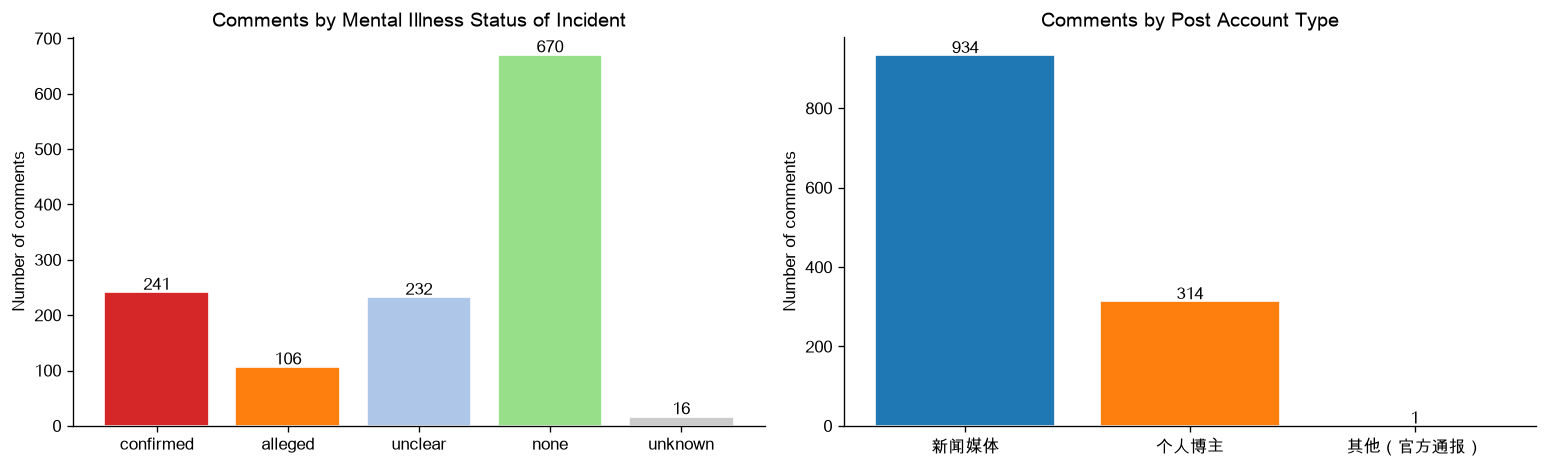

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MI group distribution
mi_counts = df['mental_illness'].value_counts().reindex(['confirmed','alleged','unclear','none','unknown']).dropna()
colors_mi = ['#d62728','#ff7f0e','#aec7e8','#98df8a','#cccccc']
axes[0].bar(mi_counts.index, mi_counts.values, color=colors_mi[:len(mi_counts)], edgecolor='white')
for i, (label, val) in enumerate(mi_counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontsize=10)
axes[0].set_title('Comments by Mental Illness Status of Incident', fontweight='bold')
axes[0].set_ylabel('Number of comments')
axes[0].spines[['top','right']].set_visible(False)

# Account type distribution
acct_counts = df['account_type'].value_counts()
axes[1].bar(acct_counts.index, acct_counts.values,
            color=['#1f77b4','#ff7f0e','#aec7e8'], edgecolor='white')
for i, val in enumerate(acct_counts.values):
    axes[1].text(i, val + 5, str(val), ha='center', fontsize=10)
axes[1].set_title('Comments by Post Account Type', fontweight='bold')
axes[1].set_ylabel('Number of comments')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 2. BERTopic Results: 25 Topics, 6 Themes

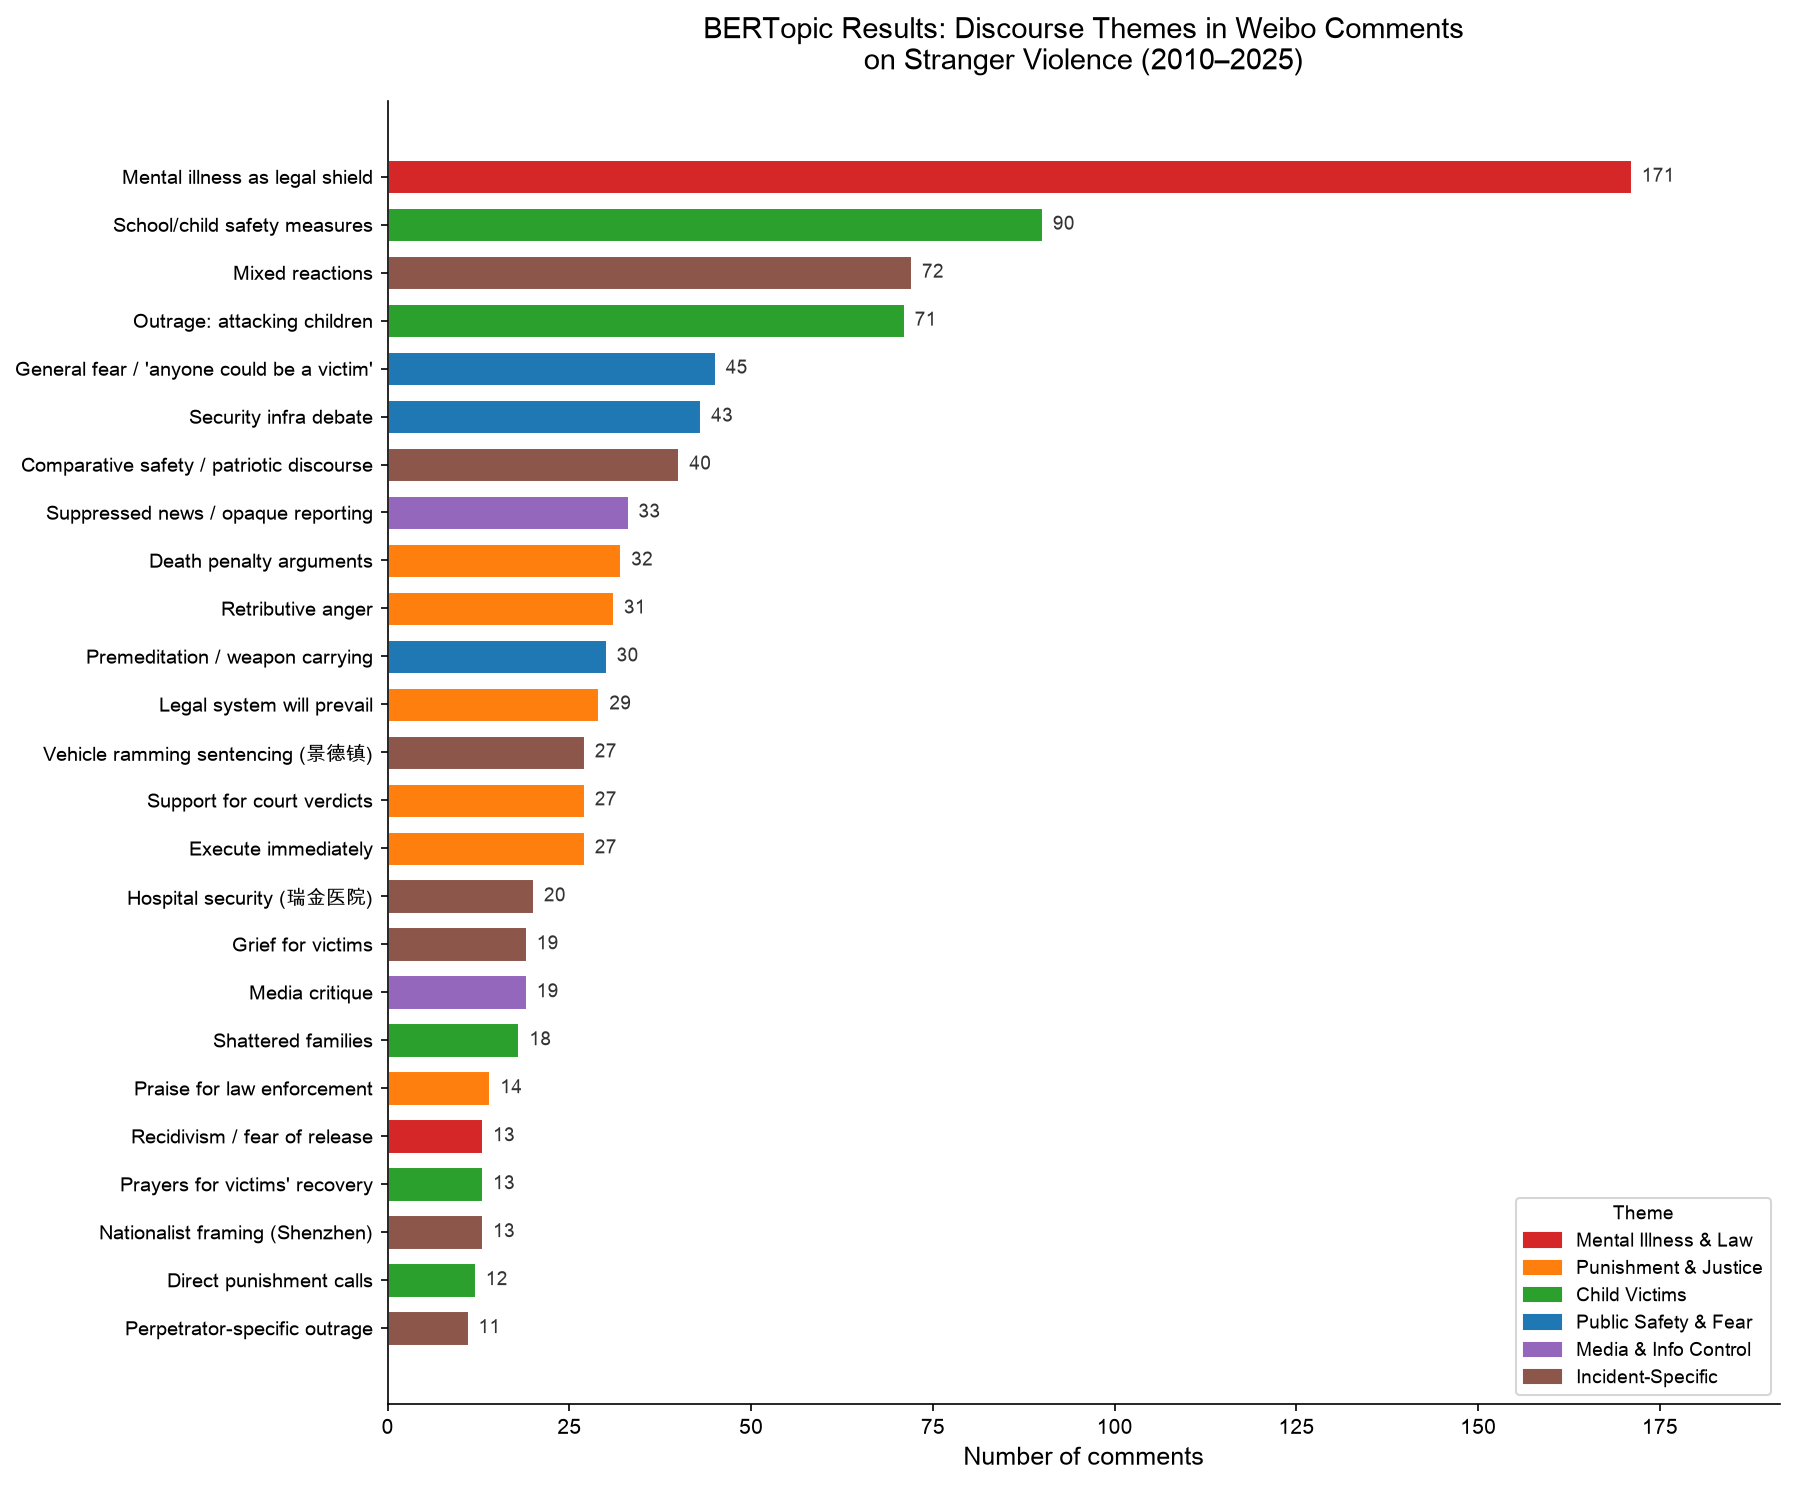

In [3]:
display(Image(str(FIG_DIR / 'topic_sizes.png'), width=850))

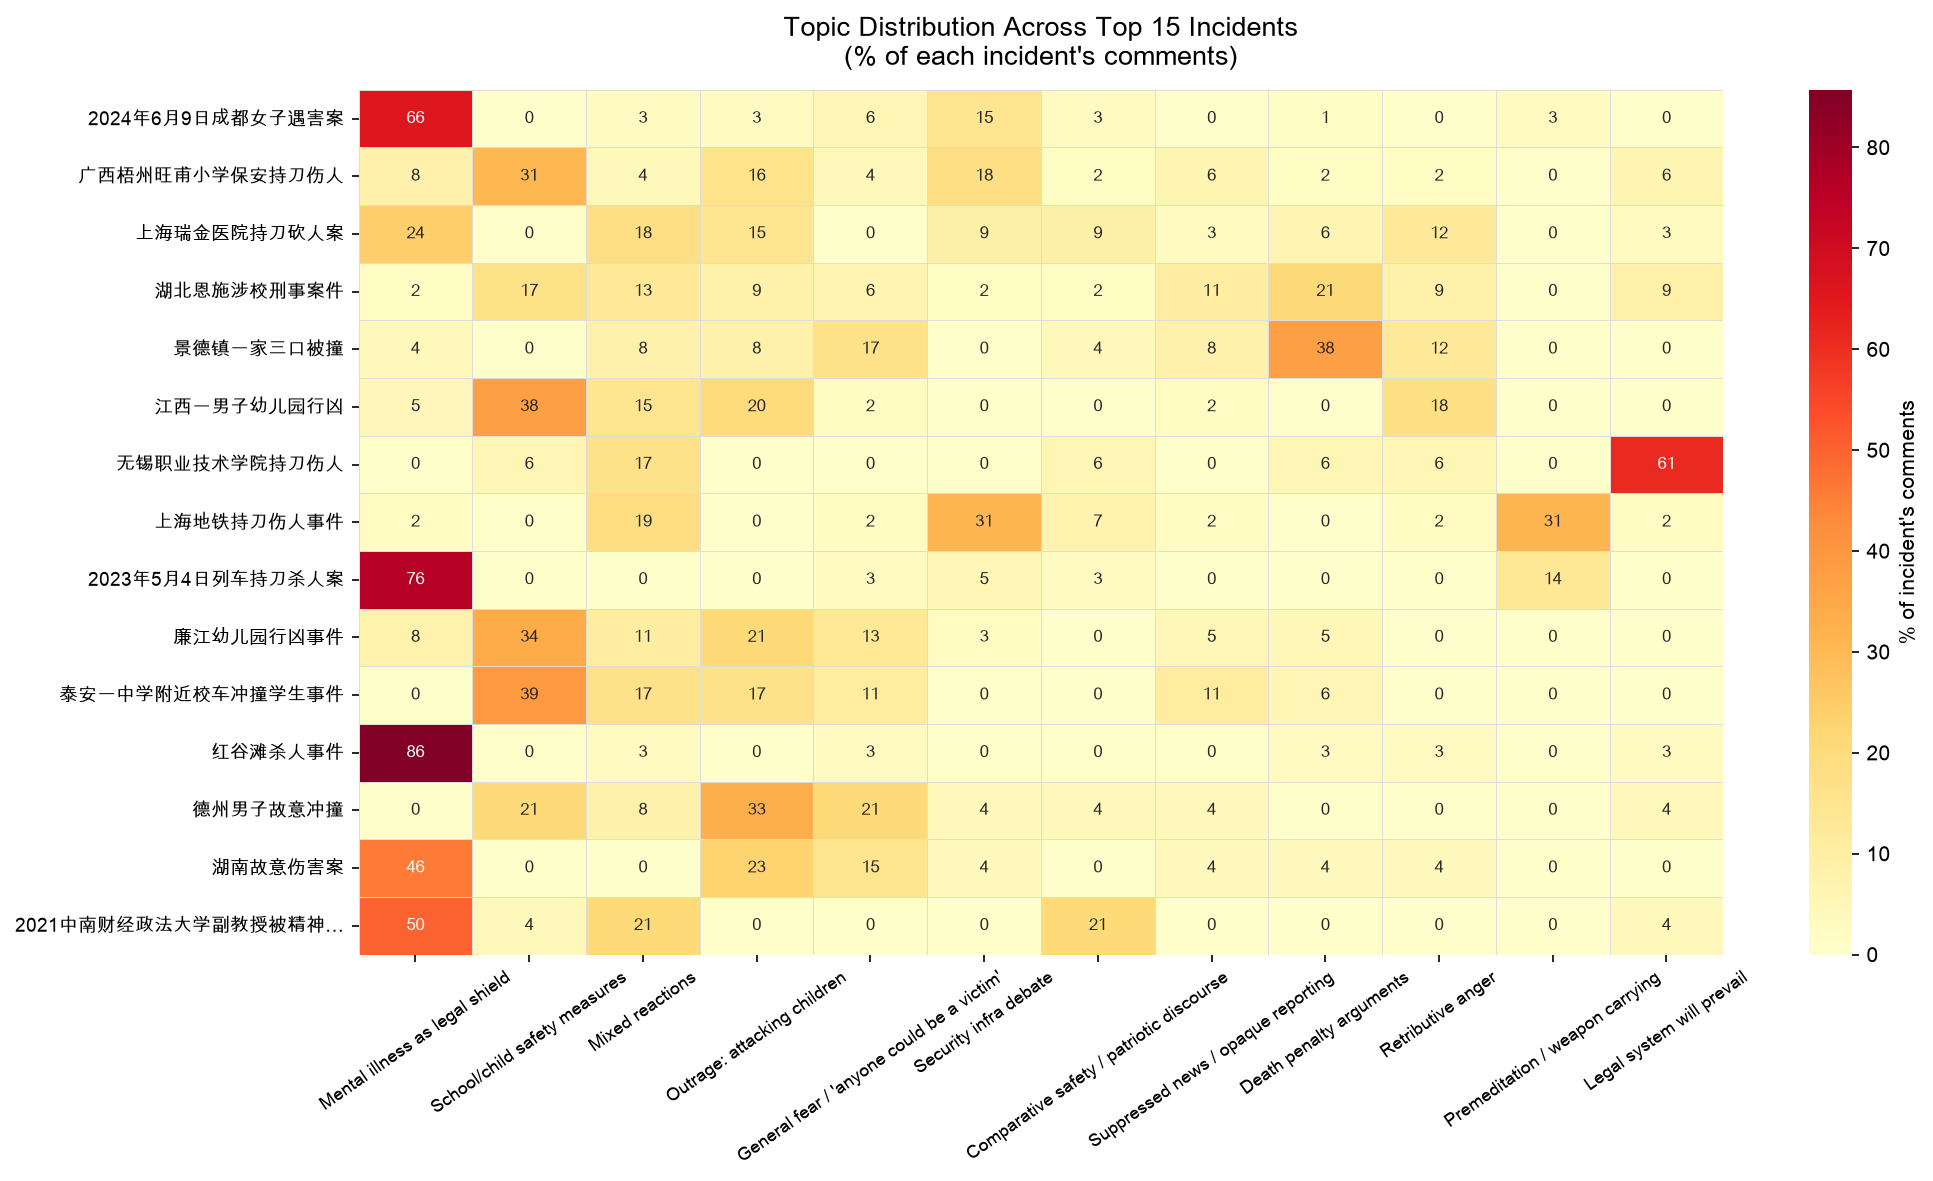

In [4]:
display(Image(str(FIG_DIR / 'topic_heatmap.png'), width=950))

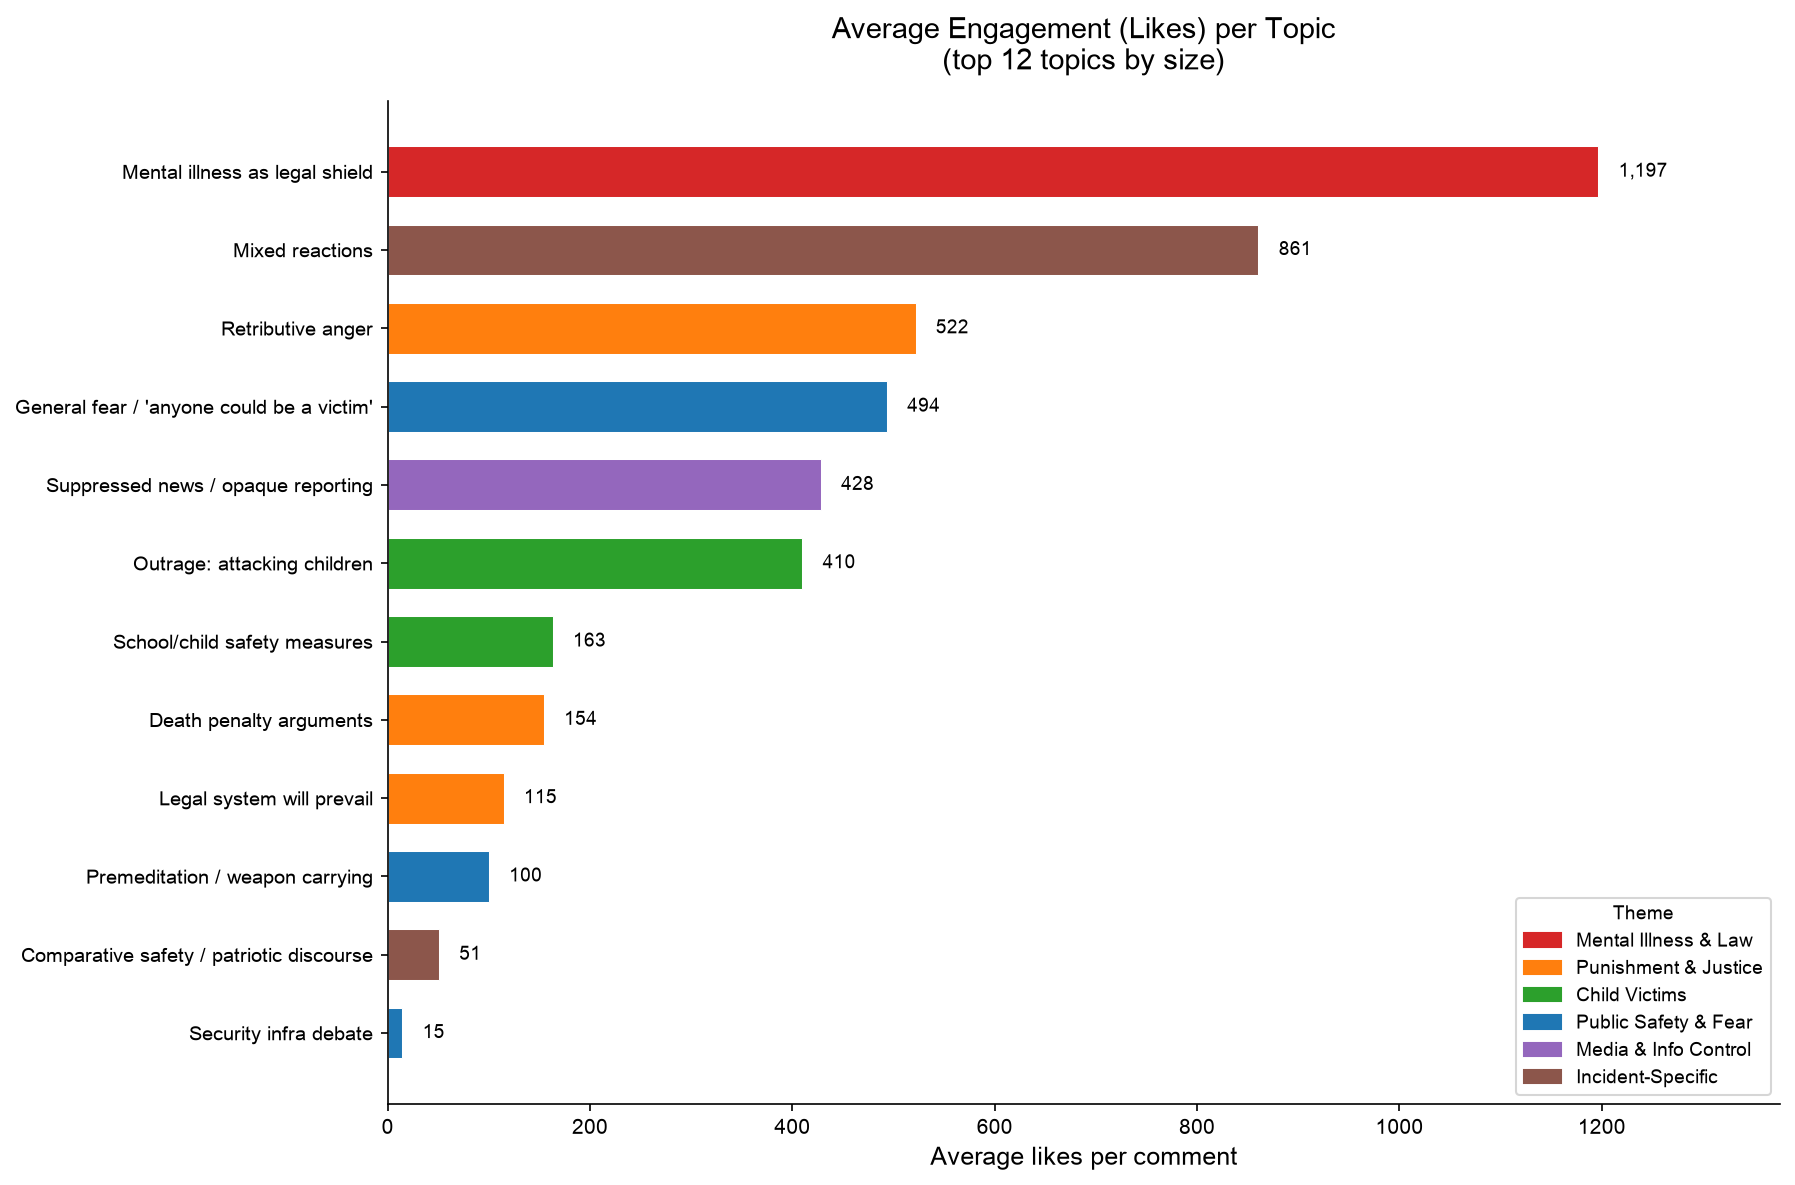

In [5]:
display(Image(str(FIG_DIR / 'topic_likes.png'), width=850))

---
## 3. Mental Illness Framing by Incident Type

Core research question: does the Mental Illness & Law discourse theme concentrate in incidents where the perpetrator was actually mentally ill?

In [12]:
MI_ORDER = ['confirmed', 'alleged', 'unclear', 'none']
present  = [g for g in MI_ORDER if g in df_t['mental_illness'].values]

pivot_mi = (
    df_t.groupby(['mental_illness', 'theme'])
        .size()
        .unstack(fill_value=0)
        .reindex(present)
)
pivot_mi_pct = pivot_mi.div(pivot_mi.sum(axis=1), axis=0) * 100

# Display table
display(pivot_mi_pct.round(1).style
    .background_gradient(cmap='Reds', subset=['Mental Illness & Law'])
    .background_gradient(cmap='Greens', subset=['Child Victims'])
    .format('{:.1f}%')
    .set_caption('Topic % by Mental Illness Status of Incident'))

theme,Child Victims,Incident-Specific,Media & Info Control,Mental Illness & Law,Public Safety & Fear,Punishment & Justice
mental_illness,,,,,,
confirmed,2.7%,14.2%,0.0%,64.5%,13.7%,4.9%
alleged,13.9%,15.3%,2.8%,43.1%,12.5%,12.5%
unclear,25.5%,24.2%,4.3%,3.1%,23.6%,19.3%
none,29.8%,24.5%,7.9%,6.1%,9.1%,22.5%


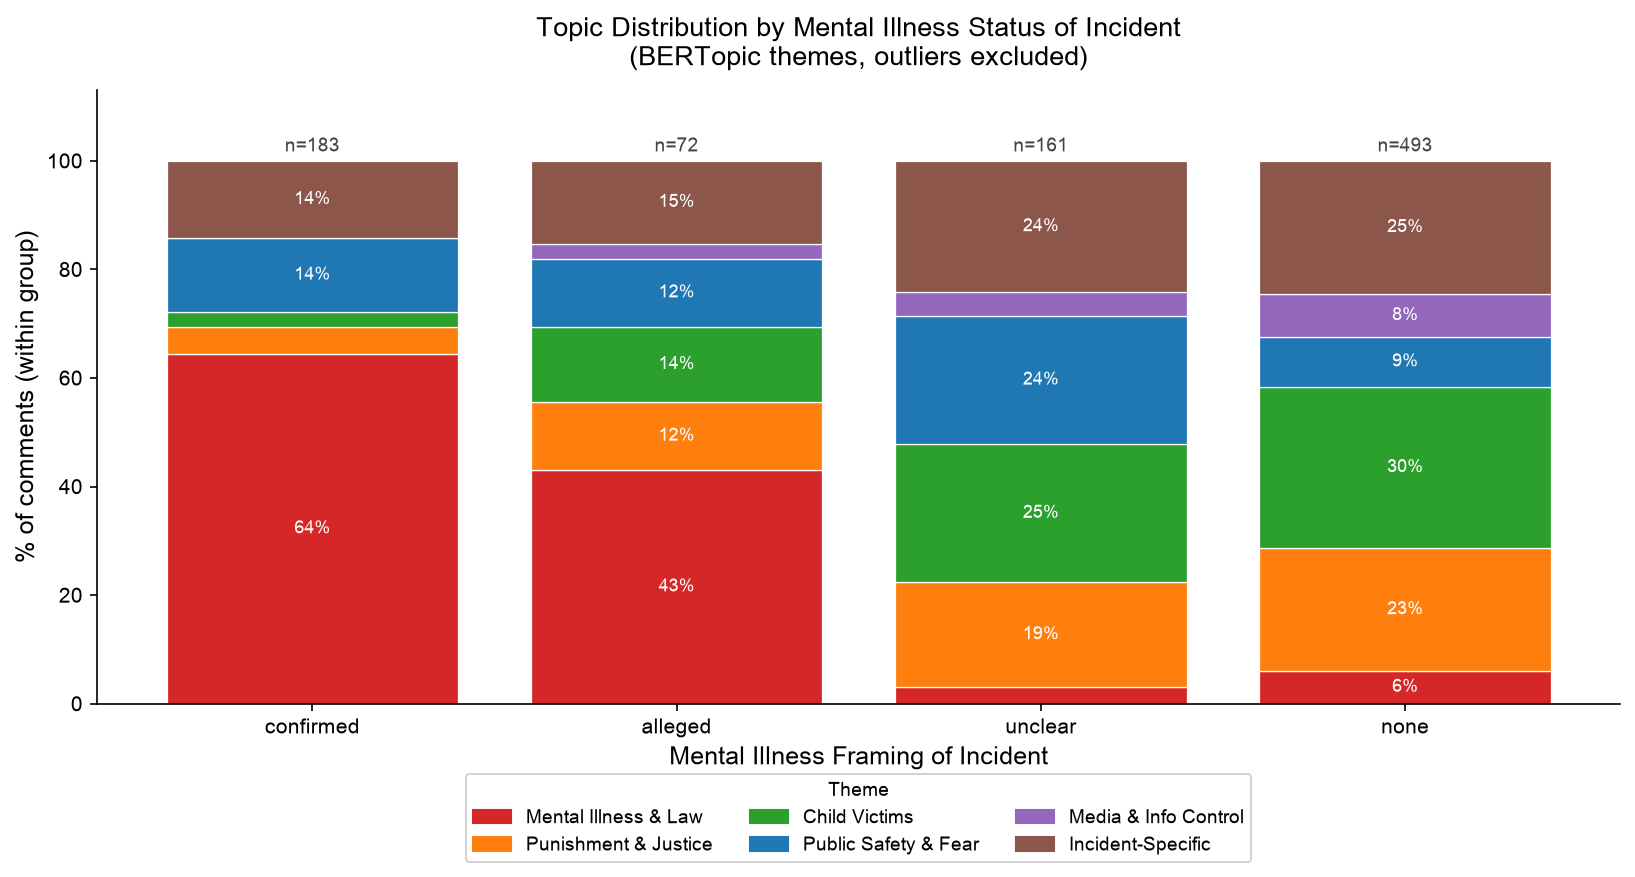

In [13]:
display(Image(str(FIG_DIR / 'mi_comparison.png'), width=800))

---
## 4. Media vs. Public Voice: Do Account Types Drive Different Discourse?

In [8]:
df_acct = df_t[df_t['account_type'].isin(['新闻媒体', '个人博主'])].copy()
df_acct['account_label'] = df_acct['account_type'].map({
    '新闻媒体': 'News Media (新闻媒体)',
    '个人博主': 'Personal Blogger (个人博主)'
})

pivot_acct = (
    df_acct.groupby(['account_label', 'theme'])
           .size()
           .unstack(fill_value=0)
)
pivot_acct_pct = pivot_acct.div(pivot_acct.sum(axis=1), axis=0) * 100

display(pivot_acct_pct.round(1).style
    .background_gradient(cmap='Reds', subset=['Mental Illness & Law'])
    .format('{:.1f}%')
    .set_caption('Topic % by Post Account Type'))

for acct in pivot_acct.index:
    print(f"{acct}: n={pivot_acct.loc[acct].sum()} comments")

theme,Child Victims,Incident-Specific,Media & Info Control,Mental Illness & Law,Public Safety & Fear,Punishment & Justice
account_label,,,,,,
News Media (新闻媒体),22.5%,23.1%,4.4%,19.6%,11.8%,18.7%
Personal Blogger (个人博主),21.9%,17.5%,7.9%,22.4%,15.8%,14.5%


News Media (新闻媒体): n=680 comments
Personal Blogger (个人博主): n=228 comments


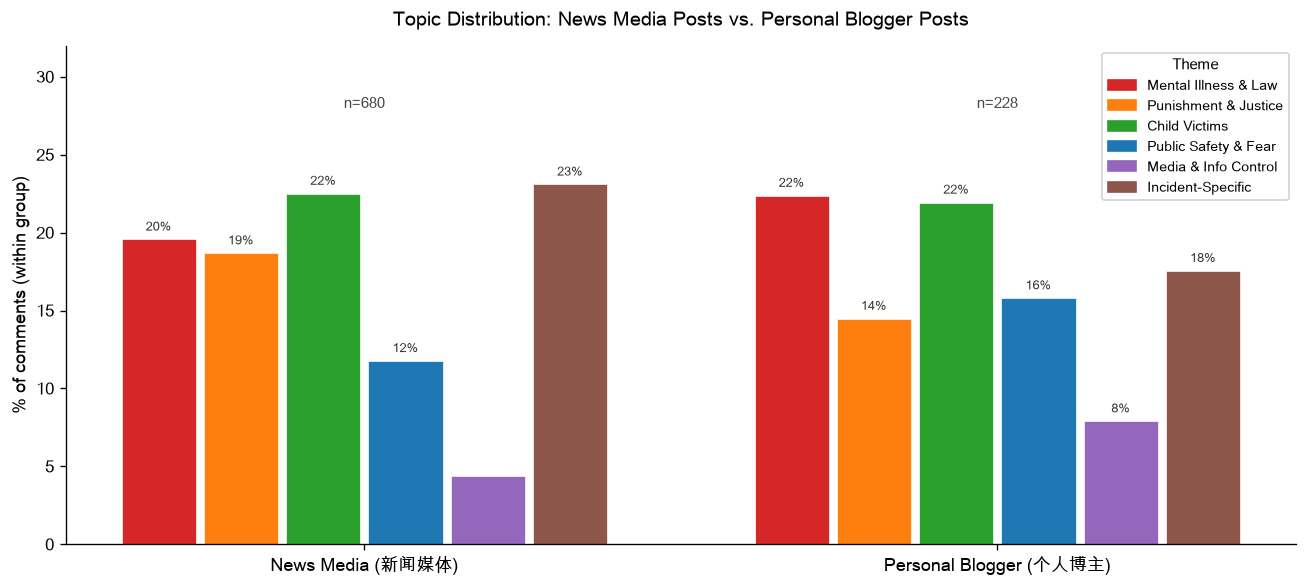

In [9]:
themes  = list(THEME_COLORS.keys())
groups  = list(pivot_acct_pct.index)
x       = np.arange(len(groups))
width   = 0.13
offsets = np.linspace(-(len(themes)-1)/2, (len(themes)-1)/2, len(themes)) * width

fig, ax = plt.subplots(figsize=(11, 5))
for offset, theme in zip(offsets, themes):
    vals = [pivot_acct_pct.loc[g, theme] if theme in pivot_acct_pct.columns else 0 for g in groups]
    bars = ax.bar(x + offset, vals, width=width * 0.9,
                  color=THEME_COLORS[theme], label=theme, edgecolor='white', linewidth=0.4)
    for bar, val in zip(bars, vals):
        if val >= 5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=7.5, color='#333')

for i, g in enumerate(groups):
    n = int(pivot_acct.loc[g].sum())
    ax.text(i, 28, f'n={n}', ha='center', fontsize=9, color='#444')

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel('% of comments (within group)', fontsize=11)
ax.set_title('Topic Distribution: News Media Posts vs. Personal Blogger Posts',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylim(0, 32)
ax.spines[['top','right']].set_visible(False)
legend_patches = [mpatches.Patch(color=THEME_COLORS[t], label=t) for t in themes]
ax.legend(handles=legend_patches, title='Theme', fontsize=8.5, title_fontsize=9,
          loc='upper right', framealpha=0.85)
plt.tight_layout()
plt.savefig(FIG_DIR / 'media_vs_public.png', dpi=150, bbox_inches='tight')
plt.show()

 Discourse patterns are broadly similar between news media posts and personal blogger posts. 


## 5. BERTopic Accuracy vs. Manual Annotation

In [10]:
valid = annot[annot['bert_correct'].notna() & (annot['bert_correct'] != '')].copy()
valid['bert_correct'] = valid['bert_correct'].str.strip().str.lower()

# Overall accuracy
acc = valid['bert_correct'].value_counts()
total = len(valid)
print('Overall BERTopic accuracy (n={})'.format(total))
for k, v in acc.items():
    print(f'  {k:10s}: {v:3d}  ({v/total*100:.1f}%)')
print()

# By theme
by_theme = (valid.groupby('theme')['bert_correct']
                 .value_counts(normalize=True)
                 .mul(100).round(1)
                 .unstack(fill_value=0))
display(by_theme.style.background_gradient(cmap='Greens', subset=['yes'])
               .format('{:.1f}%')
               .set_caption('BERTopic Accuracy by Theme (%)'))

Overall BERTopic accuracy (n=150)
  yes       : 118  (78.7%)
  no        :  27  (18.0%)
  partial   :   5  (3.3%)



bert_correct,no,partial,yes
theme,,,
Child Victims,16.0%,8.0%,76.0%
Incident-Specific,36.0%,8.0%,56.0%
Media & Info Control,24.0%,0.0%,76.0%
Mental Illness & Law,8.0%,4.0%,88.0%
Public Safety & Fear,12.0%,0.0%,88.0%
Punishment & Justice,12.0%,0.0%,88.0%


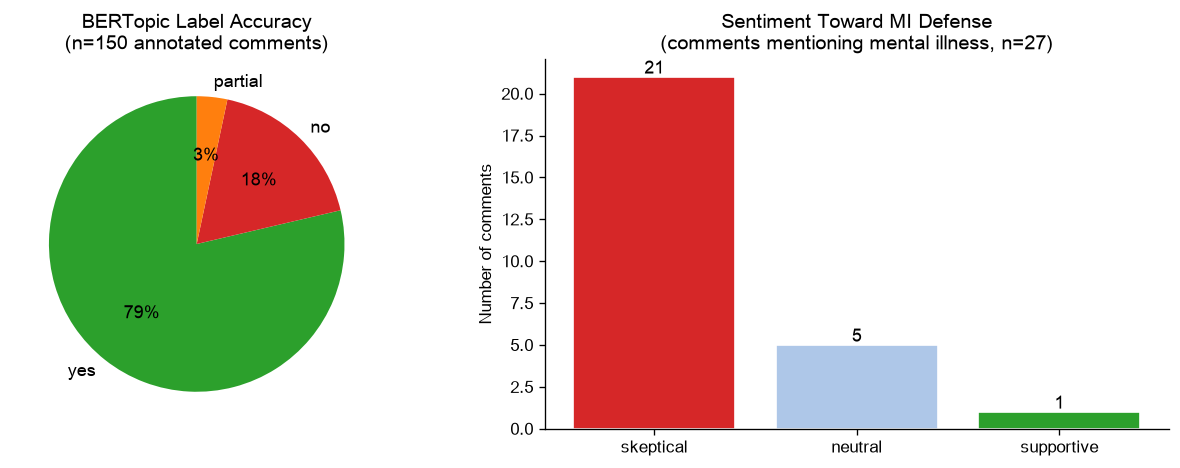

Of comments that mention mental illness:
  skeptical   : 21
  neutral     : 5
  supportive  : 1


In [11]:
# Sentiment toward MI defense
mi_comments = annot[annot['mental_illness_mentioned'].str.strip().str.lower() == 'yes'].copy()
sent = mi_comments['sentiment_toward_mi_defense'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Accuracy pie
colors_pie = ['#2ca02c', '#d62728', '#ff7f0e']
axes[0].pie(acc.values, labels=acc.index, autopct='%1.0f%%',
            colors=colors_pie[:len(acc)], startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title(f'BERTopic Label Accuracy\n(n={total} annotated comments)',
                  fontweight='bold')

# Sentiment bar
sent_colors = {'skeptical':'#d62728', 'neutral':'#aec7e8', 'supportive':'#2ca02c', 'n/a':'#cccccc'}
bars = axes[1].bar(sent.index, sent.values,
                   color=[sent_colors.get(k, '#999') for k in sent.index],
                   edgecolor='white')
for bar, val in zip(bars, sent.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', fontsize=11)
axes[1].set_title(f'Sentiment Toward MI Defense\n(comments mentioning mental illness, n={len(mi_comments)})',
                  fontweight='bold')
axes[1].set_ylabel('Number of comments')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'annotation_check.png', dpi=150, bbox_inches='tight')
plt.show()

print('Of comments that mention mental illness:')
for k, v in sent.items():
    print(f'  {k:12s}: {v}')